In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
WORK = "/content/drive/MyDrive/sickle-haemoglobin"
os.makedirs(WORK, exist_ok=True)
os.chdir(WORK)

!pip install -q gemmi biopython py3Dmol
for d in ["structures", "figures", "results"]:
    os.makedirs(d, exist_ok=True)

import gemmi, Bio
print("Working in:", os.getcwd())
print("gemmi", gemmi.__version__, "| biopython", Bio.__version__)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 82.0 MB/s eta 0:00:00
Working in: /content/drive/MyDrive/sickle-haemoglobin
gemmi 0.7.5 | biopython 1.88


In [ ]:
import gemmi

STRUCTURES = {
    "2HHB": "Normal human deoxyhaemoglobin (HbA)",
    "2HBS": "Deoxyhaemoglobin S (sickle), beta Glu6Val",
}

for pdb_id in STRUCTURES:
    path = f"structures/{pdb_id}.pdb"
    if not os.path.exists(path):
        !wget -q https://files.rcsb.org/download/{pdb_id}.pdb -O {path}

def is_amino_acid(resname):
    info = gemmi.find_tabulated_residue(resname)
    return info is not None and info.is_amino_acid()

def one_letter(resname):
    info = gemmi.find_tabulated_residue(resname)
    return info.one_letter_code.upper() if info else "X"

# Alpha-globin is 141 residues, beta-globin is 146. That is how the chains are told apart.
GLOBIN_LENGTH = {141: "alpha", 146: "beta"}

def load(pdb_id):
    st = gemmi.read_structure(f"structures/{pdb_id}.pdb")
    st.setup_entities()
    st.remove_alternative_conformations()
    st.remove_waters()
    chains = {}
    for ch in st[0]:
        n = len([r for r in ch if is_amino_acid(r.name)])
        if n in GLOBIN_LENGTH:
            chains[ch.name] = GLOBIN_LENGTH[n]
    return st, chains

def residue_at(st, chain_name, seqnum):
    for r in st[0][chain_name]:
        if r.seqid.num == seqnum:
            return r
    return None

MODELS = {}
for pdb_id, label in STRUCTURES.items():
    st, chains = load(pdb_id)
    MODELS[pdb_id] = (st, chains)
    alpha = [c for c, t in chains.items() if t == "alpha"]
    beta  = [c for c, t in chains.items() if t == "beta"]
    hets  = sorted({r.name for ch in st[0] for r in ch if not is_amino_acid(r.name)})
    print(f"{pdb_id}  {label}")
    print(f"   resolution {st.resolution} A | alpha chains {alpha} | beta chains {beta} | hetero {hets}")
    for cn in beta:
        r = residue_at(st, cn, 6)
        print(f"   beta chain {cn}, residue 6 = {r.name} ({one_letter(r.name)}), {len(r)} atoms")

2HHB  Normal human deoxyhaemoglobin (HbA)
   resolution 1.74 A | alpha chains ['A', 'C'] | beta chains ['B', 'D'] | hetero ['HEM', 'PO4']
   beta chain B, residue 6 = GLU (E), 9 atoms
   beta chain D, residue 6 = GLU (E), 9 atoms
2HBS  Deoxyhaemoglobin S (sickle), beta Glu6Val
   resolution 2.05 A | alpha chains ['A', 'C', 'E', 'G'] | beta chains ['B', 'D', 'F', 'H'] | hetero ['HEM']
   beta chain B, residue 6 = VAL (V), 7 atoms
   beta chain D, residue 6 = VAL (V), 7 atoms
   beta chain F, residue 6 = VAL (V), 7 atoms
   beta chain H, residue 6 = VAL (V), 7 atoms


In [ ]:
def sequence(st, chain_name):
    return "".join(one_letter(r.name) for r in st[0][chain_name] if is_amino_acid(r.name))

st_a, ch_a = MODELS["2HHB"]
st_s, ch_s = MODELS["2HBS"]

beta_a = sequence(st_a, [c for c, t in ch_a.items() if t == "beta"][0])
beta_s = sequence(st_s, [c for c, t in ch_s.items() if t == "beta"][0])

print(f"beta-globin length: HbA {len(beta_a)}, HbS {len(beta_s)}")
diffs = [(i + 1, a, b) for i, (a, b) in enumerate(zip(beta_a, beta_s)) if a != b]
print(f"Differences: {len(diffs)}")
for pos, a, b in diffs:
    print(f"   position {pos}: {a} (HbA) -> {b} (HbS)")

alpha_a = sequence(st_a, [c for c, t in ch_a.items() if t == "alpha"][0])
alpha_s = sequence(st_s, [c for c, t in ch_s.items() if t == "alpha"][0])
print(f"\nalpha-globin identical: {alpha_a == alpha_s}")

with open("results/sequence_check.txt", "w") as f:
    f.write(f"beta-globin differences: {diffs}\nalpha identical: {alpha_a == alpha_s}\n")

beta-globin length: HbA 146, HbS 146
Differences: 1
   position 6: E (HbA) -> V (HbS)

alpha-globin identical: True


In [ ]:
import py3Dmol

view = py3Dmol.view(width=850, height=500, viewergrid=(1, 2))
for col, (pdb_id, colour) in enumerate([("2HHB", "#0072B2"), ("2HBS", "#D55E00")]):
    st, chains = MODELS[pdb_id]
    beta = [c for c, t in chains.items() if t == "beta"][0]
    view.addModel(open(f"structures/{pdb_id}.pdb").read(), "pdb", viewer=(0, col))
    view.setStyle({"cartoon": {"color": "lightgrey", "opacity": 0.75}}, viewer=(0, col))
    view.addStyle({"chain": beta}, {"cartoon": {"color": colour}}, viewer=(0, col))
    view.addStyle({"chain": beta, "resi": 6},
                  {"stick": {"colorscheme": "greenCarbon", "radius": 0.35},
                   "sphere": {"radius": 0.6, "opacity": 0.4}}, viewer=(0, col))
    view.addStyle({"resn": "HEM"}, {"stick": {"colorscheme": "redCarbon", "radius": 0.12}}, viewer=(0, col))
    view.zoomTo({"chain": beta, "resi": 6}, viewer=(0, col))
view.show()
print("left: HbA (Glu6, blue beta chain)   right: HbS (Val6, orange beta chain)   green = residue 6")

[interactive 3D view — re-run this cell to display it]


In [ ]:
import warnings, pandas as pd
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
warnings.filterwarnings("ignore")

# Theoretical maximum solvent-accessible area per residue type (Tien et al. 2013, PLoS ONE)
MAX_ASA = {"ALA":129,"ARG":274,"ASN":195,"ASP":193,"CYS":167,"GLU":223,"GLN":225,
           "GLY":104,"HIS":224,"ILE":197,"LEU":201,"LYS":236,"MET":224,"PHE":240,
           "PRO":159,"SER":155,"THR":172,"TRP":285,"TYR":263,"VAL":174}
# Kyte-Doolittle hydropathy: positive = water-avoiding
KD = {"ILE":4.5,"VAL":4.2,"LEU":3.8,"PHE":2.8,"CYS":2.5,"MET":1.9,"ALA":1.8,"GLY":-0.4,
      "THR":-0.7,"SER":-0.8,"TRP":-0.9,"TYR":-1.3,"PRO":-1.6,"HIS":-3.2,"GLU":-3.5,
      "GLN":-3.5,"ASP":-3.5,"ASN":-3.5,"LYS":-3.9,"ARG":-4.5}
CHARGE   = {"ASP":-1,"GLU":-1,"LYS":+1,"ARG":+1}
BACKBONE = {"N","CA","C","O","OXT"}

rows = []
for pdb_id, (st, chains) in MODELS.items():
    clean = f"structures/{pdb_id}_clean.pdb"
    st.write_pdb(clean)                      # waters and altlocs already stripped
    s = PDBParser(QUIET=True).get_structure(pdb_id, clean)
    ShrakeRupley().compute(s[0], level="A")  # per-atom, so side chain can be isolated
    for ch in s[0]:
        if chains.get(ch.id) != "beta":
            continue
        for r in ch:
            if r.id[1] != 6:
                continue
            name  = r.get_resname()
            total = sum(a.sasa for a in r)
            side  = sum(a.sasa for a in r if a.get_id() not in BACKBONE)
            rows.append(dict(structure=pdb_id, chain=ch.id, residue=name,
                             sasa_total=round(total, 1),
                             sasa_sidechain=round(side, 1),
                             rel_exposure_pct=round(100 * total / MAX_ASA[name], 1),
                             hydropathy=KD[name], charge=CHARGE.get(name, 0)))

sasa = pd.DataFrame(rows)
sasa.to_csv("results/residue6_exposure.csv", index=False)
print(sasa.to_string(index=False))
print(f"\nmean relative exposure  HbA {sasa.query('structure==\"2HHB\"').rel_exposure_pct.mean():.1f}%"
      f"   HbS {sasa.query('structure==\"2HBS\"').rel_exposure_pct.mean():.1f}%")

structure chain residue  sasa_total  sasa_sidechain  rel_exposure_pct  hydropathy  charge
     2HHB     B     GLU       117.8           106.8              52.8        -3.5      -1
     2HHB     D     GLU       118.4           104.0              53.1        -3.5      -1
     2HBS     B     VAL       101.4            88.2              58.3         4.2       0
     2HBS     D     VAL       110.8           105.1              63.7         4.2       0
     2HBS     F     VAL        98.7            93.0              56.7         4.2       0
     2HBS     H     VAL        16.8            15.7               9.6         4.2       0

mean relative exposure  HbA 53.0%   HbS 47.1%


In [ ]:
import numpy as np
from scipy.spatial import cKDTree

def atom_table(st):
    """Every heavy atom in the deposited coordinates, labelled."""
    xyz, lab = [], []
    for ch in st[0]:
        for r in ch:
            for a in r:
                xyz.append([a.pos.x, a.pos.y, a.pos.z])
                lab.append((ch.name, r.seqid.num, r.name))
    return np.array(xyz), lab

env = []
for pdb_id, (st, chains) in MODELS.items():
    st.remove_hydrogens()
    xyz, lab = atom_table(st)
    tree = cKDTree(xyz)
    for cn, ctype in chains.items():
        if ctype != "beta":
            continue
        res = next(r for r in st[0][cn] if r.seqid.num == 6)
        side = [a for a in res if a.name not in BACKBONE]
        nearest = {}
        for a in side:
            p = np.array([a.pos.x, a.pos.y, a.pos.z])
            for j in tree.query_ball_point(p, 6.0):
                c2, n2, rn2 = lab[j]
                if c2 == cn and n2 == 6:        # skip itself
                    continue
                d = float(np.linalg.norm(xyz[j] - p))
                nearest[(c2, n2, rn2)] = min(nearest.get((c2, n2, rn2), 99.9), d)
        prot  = {k: v for k, v in nearest.items() if is_amino_acid(k[2])}
        phob  = [k for k in prot if KD.get(k[2], 0) > 0]
        other = {k: v for k, v in prot.items() if k[0] != cn}
        env.append(dict(structure=pdb_id, chain=cn, residue=res.name,
                        neighbours=len(prot), hydrophobic=len(phob),
                        pct_hydrophobic=round(100 * len(phob) / max(len(prot), 1)),
                        from_other_chain=len(other),
                        other_chain_partners=", ".join(
                            f"{k[0]}:{k[2]}{k[1]}" for k in sorted(other, key=other.get)[:4]) or "-"))

envdf = pd.DataFrame(env)
envdf.to_csv("results/residue6_environment.csv", index=False)
print(envdf.to_string(index=False))

structure chain residue  neighbours  hydrophobic  pct_hydrophobic  from_other_chain               other_chain_partners
     2HHB     B     GLU           5            0                0                 0                                  -
     2HHB     D     GLU           5            0                0                 0                                  -
     2HBS     B     VAL           5            0                0                 0                                  -
     2HBS     D     VAL           6            1               17                 0                                  -
     2HBS     F     VAL           6            1               17                 0                                  -
     2HBS     H     VAL          14            5               36                 8 B:ASP73, B:THR84, B:ALA70, B:PHE85


In [ ]:
def chain_charge(st, cn):
    return sum(CHARGE.get(r.name, 0) for r in st[0][cn] if is_amino_acid(r.name))

chg = []
for pdb_id, (st, chains) in MODELS.items():
    a = [c for c, t in chains.items() if t == "alpha"][0]
    b = [c for c, t in chains.items() if t == "beta"][0]
    ca, cb = chain_charge(st, a), chain_charge(st, b)
    chg.append(dict(structure=pdb_id, alpha_chain=a, alpha_charge=ca,
                    beta_chain=b, beta_charge=cb, tetramer_charge=2 * (ca + cb)))

chgdf = pd.DataFrame(chg)
chgdf.to_csv("results/formal_charge.csv", index=False)
print(chgdf.to_string(index=False))
d = chgdf.tetramer_charge.iloc[1] - chgdf.tetramer_charge.iloc[0]
print(f"\nnet change per tetramer: {d:+d}")
print("(Asp/Glu = -1, Lys/Arg = +1; His omitted, it is only partly protonated at pH 7.4)")

structure alpha_chain  alpha_charge beta_chain  beta_charge  tetramer_charge
     2HHB           A             2          B           -1                2
     2HBS           A             2          B            0                4

net change per tetramer: +2
(Asp/Glu = -1, Lys/Arg = +1; His omitted, it is only partly protonated at pH 7.4)


In [ ]:
for folder in ["structures", "results"]:
    print(f"\n{folder}/")
    for f in sorted(os.listdir(folder)):
        print(f"   {f}  ({os.path.getsize(folder + '/' + f):,} bytes)")
print("\nAll of this is on Google Drive and survives a runtime disconnect.")


structures/
   2HBS.pdb  (871,803 bytes)
   2HBS_clean.pdb  (789,750 bytes)
   2HHB.pdb  (453,438 bytes)
   2HHB_clean.pdb  (416,178 bytes)

results/
   formal_charge.csv  (105 bytes)
   residue6_environment.csv  (266 bytes)
   residue6_exposure.csv  (287 bytes)
   sequence_check.txt  (63 bytes)

All of this is on Google Drive and survives a runtime disconnect.


In [ ]:
CONTACT_CUTOFF = 5.0

def atom_table_full(st):
    xyz, lab = [], []
    for ch in st[0]:
        for r in ch:
            for a in r:
                xyz.append([a.pos.x, a.pos.y, a.pos.z])
                lab.append((ch.name, r.seqid.num, r.name, a.name))
    return np.array(xyz), lab

contacts = []
for pdb_id, (st, chains) in MODELS.items():
    xyz, lab = atom_table_full(st)
    tree = cKDTree(xyz)
    for cn, ctype in chains.items():
        if ctype != "beta":
            continue
        res = next(r for r in st[0][cn] if r.seqid.num == 6)
        for a in res:
            if a.name in BACKBONE:
                continue
            p = np.array([a.pos.x, a.pos.y, a.pos.z])
            for j in tree.query_ball_point(p, CONTACT_CUTOFF):
                c2, n2, rn2, an2 = lab[j]
                if c2 == cn:                       # intermolecular only
                    continue
                contacts.append(dict(structure=pdb_id,
                                     donor_chain=cn, donor_res=res.name, donor_atom=a.name,
                                     partner_chain=c2, partner_res=f"{rn2}{n2}", partner_atom=an2,
                                     distance=round(float(np.linalg.norm(xyz[j] - p)), 2),
                                     partner_hydropathy=KD.get(rn2, 0)))

cdf = pd.DataFrame(contacts).sort_values("distance")
cdf.to_csv("results/intermolecular_contacts.csv", index=False)

if cdf.empty:
    print("No intermolecular contacts to residue 6 in the deposited coordinates.")
else:
    print(cdf.to_string(index=False))
    print("\nPartner residues, closest approach:")
    print(cdf.groupby(["structure", "donor_chain", "partner_chain", "partner_res",
                       "partner_hydropathy"]).distance.min()
             .reset_index().sort_values("distance").to_string(index=False))

structure donor_chain donor_res donor_atom partner_chain partner_res partner_atom  distance  partner_hydropathy
     2HBS           H       VAL         CB             B       ASP73          OD2      3.10                -3.5
     2HBS           H       VAL        CG2             B       ASP73          OD2      3.43                -3.5
     2HBS           H       VAL        CG1             B       THR84            O      3.62                -0.7
     2HBS           H       VAL        CG1             B       ASP73          OD2      3.73                -3.5
     2HBS           H       VAL        CG2             B       ASP73           CB      3.80                -3.5
     2HBS           H       VAL        CG2             B       ALA70           CB      3.83                 1.8
     2HBS           H       VAL        CG2             B       ALA70            O      3.85                 1.8
     2HBS           H       VAL        CG2             B       ALA70           CA      3.91             

In [ ]:
import copy
POCKET = [70, 73, 84, 85, 88]   # acceptor pocket residues on the beta chain

def sidechain_sasa(model, keep_chains, targets):
    """targets = list of (chain, resnum). Returns side-chain SASA with only keep_chains present."""
    m = copy.deepcopy(model)
    for cid in [c.id for c in m]:
        if cid not in keep_chains:
            m.detach_child(cid)
    ShrakeRupley().compute(m, level="A")
    out = {}
    for cid, num in targets:
        if cid not in [c.id for c in m]:
            continue
        for r in m[cid]:
            if r.id[1] == num:
                out[(cid, num)] = round(sum(a.sasa for a in r if a.get_id() not in BACKBONE), 1)
    return out

# --- buried area of the engaged valine ---
if not cdf.empty:
    pair = cdf.iloc[0]
    donor, acceptor = pair.donor_chain, pair.partner_chain
    st, chains = MODELS[pair.structure]
    s = PDBParser(QUIET=True).get_structure("x", f"structures/{pair.structure}_clean.pdb")
    alone = sidechain_sasa(s[0], {donor}, [(donor, 6)])[(donor, 6)]
    bound = sidechain_sasa(s[0], {donor, acceptor}, [(donor, 6)])[(donor, 6)]
    print(f"{pair.structure}: chain {donor} Val6 side chain")
    print(f"   alone                {alone:6.1f} A^2")
    print(f"   docked into chain {acceptor}  {bound:6.1f} A^2")
    print(f"   buried by contact    {alone - bound:6.1f} A^2  ({100*(alone-bound)/alone:.0f}% of its surface)\n")

# --- is the pocket present in HbA as well? ---
pocket_rows = []
for pdb_id, (st, chains) in MODELS.items():
    s = PDBParser(QUIET=True).get_structure(pdb_id, f"structures/{pdb_id}_clean.pdb")
    betas = [c for c, t in chains.items() if t == "beta"]
    full = sidechain_sasa(s[0], set(chains), [(c, n) for c in betas for n in POCKET])
    for (cid, num), v in full.items():
        res = next(r for r in MODELS[pdb_id][0][0][cid] if r.seqid.num == num)
        pocket_rows.append(dict(structure=pdb_id, chain=cid, position=num,
                                residue=res.name, sidechain_sasa=v))

pdf = pd.DataFrame(pocket_rows).sort_values(["structure", "position", "chain"])
pdf.to_csv("results/acceptor_pocket_exposure.csv", index=False)
print(pdf.pivot_table(index=["structure", "position", "residue"],
                      columns="chain", values="sidechain_sasa").to_string())

2HBS: chain H Val6 side chain
   alone                 108.7 A^2
   docked into chain B    15.7 A^2
   buried by contact      93.0 A^2  (86% of its surface)

chain                          B     D     F     H
structure position residue                        
2HBS      70       ALA       0.0   9.7   6.0  10.9
          73       ASP      22.6  78.6  84.8  97.4
          84       THR      15.7  14.5  17.4  16.4
          85       PHE       0.0   2.4   4.8   1.2
          88       LEU       1.2  25.4  26.6  30.2
2HHB      70       ALA       8.5   8.5   NaN   NaN
          73       ASP      99.2  91.2   NaN   NaN
          84       THR      23.5  17.7   NaN   NaN
          85       PHE       6.0   2.4   NaN   NaN
          88       LEU      29.0  36.2   NaN   NaN


In [ ]:
import itertools

def symmetry_neighbours(st, query_xyz, pad=12.0):
    """All atoms of symmetry- and lattice-related copies near query_xyz. Excludes the deposited copy."""
    if not st.spacegroup_hm:
        return np.empty((0, 3)), np.empty((0, 3), dtype=object), []
    sg = gemmi.find_spacegroup_by_name(st.spacegroup_hm)
    if sg is None:
        return np.empty((0, 3)), np.empty((0, 3), dtype=object), []
    F, O = np.array(st.cell.frac.mat), np.array(st.cell.orth.mat)
    xyz, lab = [], []
    for ch in st[0]:
        for r in ch:
            for a in r:
                xyz.append([a.pos.x, a.pos.y, a.pos.z]); lab.append((ch.name, r.seqid.num, r.name))
    xyz = np.array(xyz); lab = np.array(lab, dtype=object)
    frac = xyz @ F.T
    lo, hi = query_xyz.min(0) - pad, query_xyz.max(0) + pad
    P, L, C = [], [], []
    for oi, op in enumerate(sg.operations()):
        M = np.array(op.float_seitz())
        f2 = frac @ M[:3, :3].T + M[:3, 3]
        for sh in itertools.product((-1, 0, 1), repeat=3):
            if oi == 0 and sh == (0, 0, 0):
                continue                                   # the deposited copy itself
            cart = (f2 + np.array(sh)) @ O.T
            k = np.all((cart >= lo) & (cart <= hi), axis=1)
            if k.any():
                P.append(cart[k]); L.append(lab[k])
                C += [f"{op.triplet()} + {sh}"] * int(k.sum())
    if not P:
        return np.empty((0, 3)), np.empty((0, 3), dtype=object), []
    return np.vstack(P), np.vstack(L), C

sym_rows = []
for pdb_id, (st, chains) in MODELS.items():
    print(f"{pdb_id}: spacegroup {st.spacegroup_hm or 'none'}, cell {st.cell}")
    betas = [c for c, t in chains.items() if t == "beta"]
    q = np.array([[a.pos.x, a.pos.y, a.pos.z]
                  for c in betas
                  for r in st[0][c] if r.seqid.num == 6
                  for a in r if a.name not in BACKBONE])
    P, L, C = symmetry_neighbours(st, q)
    print(f"   {len(P)} atoms from symmetry-related molecules within reach")
    if len(P) == 0:
        continue
    tree = cKDTree(P)
    for cn in betas:
        res = next(r for r in st[0][cn] if r.seqid.num == 6)
        hits = {}
        for a in res:
            if a.name in BACKBONE:
                continue
            p = np.array([a.pos.x, a.pos.y, a.pos.z])
            for j in tree.query_ball_point(p, CONTACT_CUTOFF):
                c2, n2, rn2 = L[j]
                if not is_amino_acid(rn2):
                    continue
                d = float(np.linalg.norm(P[j] - p))
                k = (c2, int(n2), rn2, C[j])
                hits[k] = min(hits.get(k, 99.9), d)
        for (c2, n2, rn2, code), d in sorted(hits.items(), key=lambda kv: kv[1]):
            sym_rows.append(dict(structure=pdb_id, chain=cn, residue=res.name,
                                 partner=f"{c2}:{rn2}{n2}", distance=round(d, 2),
                                 hydropathy=KD.get(rn2, 0), symmetry_op=code))

symdf = pd.DataFrame(sym_rows)
symdf.to_csv("results/symmetry_contacts.csv", index=False)
print()
print(symdf.to_string(index=False) if not symdf.empty else "No symmetry contacts within cutoff.")

2HHB: spacegroup P 1 21 1, cell <gemmi.UnitCell(63.15, 83.59, 53.8, 90, 99.34, 90)>
   633 atoms from symmetry-related molecules within reach
2HBS: spacegroup P 1 21 1, cell <gemmi.UnitCell(63.344, 185.681, 52.933, 90, 92.74, 90)>
   3535 atoms from symmetry-related molecules within reach

structure chain residue partner  distance  hydropathy              symmetry_op
     2HHB     B     GLU A:ASN68      3.63        -3.5 -x,y+1/2,-z + (1, -1, 1)
     2HHB     B     GLU A:ASP64      4.29        -3.5 -x,y+1/2,-z + (1, -1, 1)
     2HHB     B     GLU A:HIS72      4.99        -3.2 -x,y+1/2,-z + (1, -1, 1)
     2HBS     D     VAL F:ASP73      3.68        -3.5       x,y,z + (-1, 0, 0)
     2HBS     D     VAL F:THR84      3.72        -0.7       x,y,z + (-1, 0, 0)
     2HBS     D     VAL F:ALA70      3.79         1.8       x,y,z + (-1, 0, 0)
     2HBS     D     VAL F:PHE85      4.10         2.8       x,y,z + (-1, 0, 0)
     2HBS     D     VAL F:LEU88      4.10         3.8       x,y,z + (-1, 0, 0

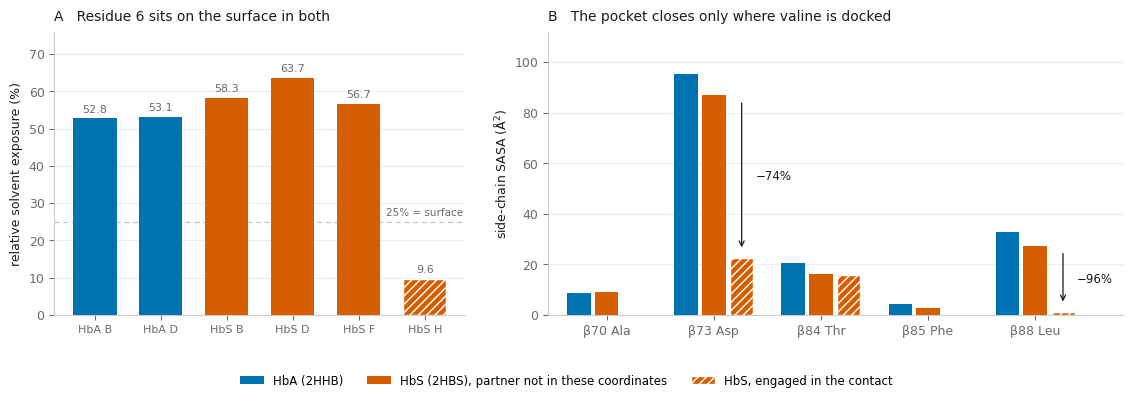

figure 1 saved


In [8]:
from matplotlib.patches import Patch

exp  = pd.read_csv("results/residue6_exposure.csv")
pock = pd.read_csv("results/acceptor_pocket_exposure.csv")
exp  = exp.assign(_o=exp.structure.map({NORMAL:0, SICKLE:1})).sort_values(["_o","chain"]).reset_index(drop=True)
lab  = [("HbA " if r.structure == NORMAL else "HbS ") + r.chain for r in exp.itertuples()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 3.9), gridspec_kw={"width_ratios":[1, 1.4]})

bars = ax1.bar(lab, exp.rel_exposure_pct, width=0.66, zorder=3,
               color=[HBA if s == NORMAL else HBS for s in exp.structure])
for b, r in zip(bars, exp.itertuples()):
    if r.chain in DONORS and r.structure == SICKLE:
        b.set_hatch("////"); b.set_edgecolor("white")
    ax1.text(b.get_x()+b.get_width()/2, r.rel_exposure_pct+1.6, f"{r.rel_exposure_pct:.1f}",
             ha="center", fontsize=8, color=MUTED)
ax1.axhline(25, ls=(0,(4,3)), lw=0.9, color="#c4c4c4", zorder=2)
ax1.text(4.42, 26.5, "25% = surface", fontsize=7.5, color=MUTED)
ax1.set_ylabel("relative solvent exposure (%)"); ax1.set_ylim(0, 76)
ax1.set_title("A   Residue 6 sits on the surface in both", loc="left", fontsize=10, color=INK, pad=8)
ax1.grid(axis="y", color=GRID, lw=0.8, zorder=0); ax1.set_axisbelow(True)
ax1.tick_params(axis="x", labelsize=8)

POS  = sorted(int(p) for p in pock.position.unique())
NAME = {p: pock[pock.position == p].residue.iloc[0].title() for p in POS}
free = sorted(set(pock.query("structure == @SICKLE").chain) - ACCEPTORS)

def sasa(stn, pos, chains):
    v = pock[(pock.structure==stn) & (pock.position==pos) & (pock.chain.isin(chains))].sidechain_sasa
    return float(v.mean()) if len(v) else np.nan

w = 0.26
for k, (c, stn, chs, hatch) in enumerate([
        (HBA, NORMAL, sorted(pock.query("structure == @NORMAL").chain.unique()), False),
        (HBS, SICKLE, free, False),
        (HBS, SICKLE, sorted(ACCEPTORS), True)]):
    bb = ax2.bar(np.arange(len(POS))+(k-1)*w, [sasa(stn,p,chs) for p in POS],
                 width=w*0.84, color=c, zorder=3)
    if hatch:
        for b in bb: b.set_hatch("////"); b.set_edgecolor("white")
ax2.set_xticks(np.arange(len(POS)))
ax2.set_xticklabels([f"β{p} {NAME[p]}" for p in POS])
ax2.set_ylabel("side-chain SASA (Å$^2$)"); ax2.set_ylim(0, 112); ax2.set_xlim(-0.55, len(POS)-0.18)
ax2.set_title("B   The pocket closes only where valine is docked", loc="left", fontsize=10, color=INK, pad=8)
ax2.grid(axis="y", color=GRID, lw=0.8, zorder=0); ax2.set_axisbelow(True)
for i, p in enumerate(POS):
    occ, fr = sasa(SICKLE, p, ACCEPTORS), sasa(SICKLE, p, free)
    if fr > 12 and occ < 0.55*fr:
        ax2.annotate("", xy=(i+w, occ+3), xytext=(i+w, fr-2),
                     arrowprops=dict(arrowstyle="->", lw=0.9, color=INK), zorder=6)
        ax2.text(i+w+0.13, (occ+fr)/2, f"−{round(100*(fr-occ)/fr)}%", fontsize=8.5, color=INK, va="center")

fig.legend(handles=[Patch(facecolor=HBA, label="HbA (2HHB)"),
                    Patch(facecolor=HBS, label="HbS (2HBS), partner not in these coordinates"),
                    Patch(facecolor=HBS, hatch="////", edgecolor="white", label="HbS, engaged in the contact")],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5,-0.03), fontsize=8.5)
fig.tight_layout(rect=[0,0.09,1,1])
fig.savefig("figures/01_exposure_and_pocket.png", dpi=200, bbox_inches="tight")
plt.show()
print("figure 1 saved")

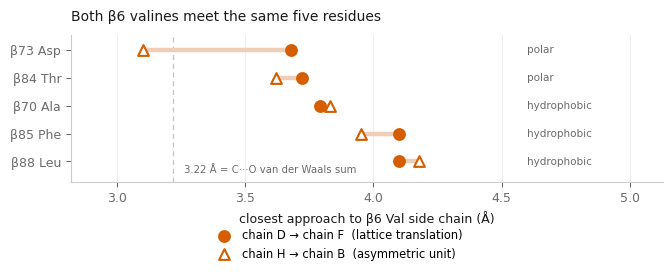

In [ ]:
def split_partner(s):
    m = re.match(r"([A-Za-z0-9]+):([A-Z]{3})(\d+)", s)
    return (m.group(1), m.group(2), int(m.group(3))) if m else (None, None, None)

direct = (cdf.query("structure == @SICKLE").rename(columns={"partner_res":"res"})
             .groupby(["donor_chain","partner_chain","res","partner_hydropathy"])
             .distance.min().reset_index())
symS = sym.query("structure == @SICKLE").copy()
if not symS.empty:
    symS[["partner_chain","rn","num"]] = symS.partner.apply(lambda s: pd.Series(split_partner(s)))
    symS["res"] = symS.rn + symS.num.astype(str)
    symS = (symS.rename(columns={"chain":"donor_chain","hydropathy":"partner_hydropathy"})
                .groupby(["donor_chain","partner_chain","res","partner_hydropathy"])
                .distance.min().reset_index())
pairs = pd.concat([direct.assign(kind="asymmetric unit"),
                   symS.assign(kind="lattice translation")], ignore_index=True)
shared = sorted(set.intersection(*[set(g.res) for _, g in pairs.groupby(["donor_chain","partner_chain"])]))
pairs = pairs[pairs.res.isin(shared)]
order = list(pairs[pairs.kind == "asymmetric unit"].set_index("res").distance.sort_values().index)
y = np.arange(len(order))[::-1]

fig2, ax = plt.subplots(figsize=(6.8, 3.6))
for yi, r in zip(y, order):
    d = pairs[pairs.res == r].distance
    ax.plot([d.min(), d.max()], [yi, yi], color=PALE, lw=3.2, solid_capstyle="round", zorder=2)
for mi, ((dc, pc, kind), g) in enumerate(pairs.groupby(["donor_chain","partner_chain","kind"])):
    g = g.set_index("res").reindex(order)
    ax.scatter(g.distance, y, s=60, marker=["o","^","s","D"][mi % 4],
               color=HBS if mi == 0 else "white", edgecolor=HBS, lw=1.5, zorder=4,
               label=f"chain {dc} → chain {pc}  ({kind})")
ax.set_yticks(y)
ax.set_yticklabels([f"β{re.sub('[A-Z]+','',r)} {re.sub('[0-9]+','',r).title()}" for r in order])
hyd = pairs.drop_duplicates("res").set_index("res").partner_hydropathy
for yi, r in zip(y, order):
    ax.text(pairs.distance.max()+0.42, yi, "hydrophobic" if hyd[r] > 0 else "polar",
            fontsize=7.5, color=MUTED, va="center")
ax.set_xlabel("closest approach to β6 Val side chain (Å)")
ax.set_xlim(pairs.distance.min()-0.28, pairs.distance.max()+0.95)
ax.set_ylim(-0.75, len(order)-0.45)
ax.axvline(3.22, ls=(0,(4,3)), lw=0.9, color="#c4c4c4", zorder=1)
ax.text(3.26, -0.5, "3.22 Å = C···O van der Waals sum", fontsize=7.3, color=MUTED, ha="left", va="bottom")
ax.grid(axis="x", color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
ax.set_title("Both β6 valines meet the same five residues", loc="left", fontsize=10, color=INK, pad=10)
ax.legend(loc="lower center", bbox_to_anchor=(0.45,-0.60), frameon=False, fontsize=8.3, handletextpad=0.6)
fig2.tight_layout(); fig2.savefig("figures/02_contact_geometry.png", dpi=200, bbox_inches="tight")
plt.show()

In [4]:
from google.colab import drive
drive.mount("/content/drive")

import os
WORK = "/content/drive/MyDrive/sickle-haemoglobin"
os.chdir(WORK)
!pip install -q gemmi biopython py3Dmol

import re, warnings, numpy as np, pandas as pd, gemmi, py3Dmol
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from Bio.PDB import PDBParser
from Bio.PDB.SASA import ShrakeRupley
warnings.filterwarnings("ignore")

BACKBONE = {"N","CA","C","O","OXT"}
MAX_ASA = {"ALA":129,"ARG":274,"ASN":195,"ASP":193,"CYS":167,"GLU":223,"GLN":225,
           "GLY":104,"HIS":224,"ILE":197,"LEU":201,"LYS":236,"MET":224,"PHE":240,
           "PRO":159,"SER":155,"THR":172,"TRP":285,"TYR":263,"VAL":174}
KD = {"ILE":4.5,"VAL":4.2,"LEU":3.8,"PHE":2.8,"CYS":2.5,"MET":1.9,"ALA":1.8,"GLY":-0.4,
      "THR":-0.7,"SER":-0.8,"TRP":-0.9,"TYR":-1.3,"PRO":-1.6,"HIS":-3.2,"GLU":-3.5,
      "GLN":-3.5,"ASP":-3.5,"ASN":-3.5,"LYS":-3.9,"ARG":-4.5}
CHARGE = {"ASP":-1,"GLU":-1,"LYS":+1,"ARG":+1}
HBA, HBS, INK, MUTED, GRID, PALE = "#0072B2","#D55E00","#1a1a1a","#6b6b6b","#ededed","#f0cdb6"
plt.rcParams.update({"font.size":9,"axes.edgecolor":"#cccccc","axes.linewidth":0.8,
 "xtick.color":MUTED,"ytick.color":MUTED,"axes.labelcolor":INK,"figure.facecolor":"white",
 "axes.spines.top":False,"axes.spines.right":False,"savefig.facecolor":"white"})

def is_amino_acid(resname):
    i = gemmi.find_tabulated_residue(resname)
    return i is not None and i.is_amino_acid()

NORMAL, SICKLE = "2HHB", "2HBS"
exp  = pd.read_csv("results/residue6_exposure.csv")
pock = pd.read_csv("results/acceptor_pocket_exposure.csv")
cdf  = pd.read_csv("results/intermolecular_contacts.csv")
sym  = pd.read_csv("results/symmetry_contacts.csv")
ACCEPTORS = set(cdf.query("structure == @SICKLE").partner_chain.unique())
DONORS    = set(cdf.query("structure == @SICKLE").donor_chain.unique())

GLOBIN_LENGTH = {141: "alpha", 146: "beta"}
MODELS = {}
for pdb_id in (NORMAL, SICKLE):
    st = gemmi.read_structure(f"structures/{pdb_id}.pdb")
    st.setup_entities(); st.remove_alternative_conformations()
    st.remove_waters(); st.remove_hydrogens()
    chains = {ch.name: GLOBIN_LENGTH[n]
              for ch in st[0]
              if (n := len([r for r in ch if is_amino_acid(r.name)])) in GLOBIN_LENGTH}
    MODELS[pdb_id] = (st, chains)

print("restored tables :", {k: len(v) for k, v in dict(exp=exp, pock=pock, cdf=cdf, sym=sym).items()})
print("donors          :", sorted(DONORS), "| acceptors:", sorted(ACCEPTORS))
print("structures      :", {k: len(v[1]) for k, v in MODELS.items()}, "globin chains")
print("figures present :", sorted(os.listdir("figures")) or "none yet")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.9 MB/s eta 0:00:00
restored tables : {'exp': 6, 'pock': 30, 'cdf': 23, 'sym': 8}
donors          : ['H'] | acceptors: ['B']
structures      : {'2HHB': 4, '2HBS': 8} globin chains
figures present : ['02_contact_geometry.png']


In [6]:
donor    = sorted(DONORS)[0]
acceptor = sorted(ACCEPTORS)[0]
pocket_resi = [int(p) for p in sorted(pock.position.unique())]   # py3Dmol needs plain ints, not numpy

view = py3Dmol.view(width=900, height=600)
view.addModel(open(f"structures/{SICKLE}.pdb").read(), "pdb")
view.setStyle({}, {"cartoon": {"color": "#e8e8e8", "opacity": 0.28}})
view.setStyle({"chain": acceptor}, {"cartoon": {"color": "#0072B2", "opacity": 0.85}})
view.setStyle({"chain": donor},    {"cartoon": {"color": "#D55E00", "opacity": 0.85}})
view.addSurface("VDW", {"opacity": 0.72, "color": "#9ecae1"},
                {"chain": acceptor, "resi": pocket_resi})
view.addStyle({"chain": acceptor, "resi": pocket_resi},
              {"stick": {"colorscheme": "cyanCarbon", "radius": 0.18}})
view.addStyle({"chain": donor, "resi": 6},
              {"stick": {"colorscheme": "orangeCarbon", "radius": 0.32},
               "sphere": {"colorscheme": "orangeCarbon", "scale": 0.34}})
view.addResLabels({"chain": acceptor, "resi": pocket_resi},
                  {"fontSize": 11, "showBackground": False, "fontColor": "#1a1a1a"})
view.zoomTo({"chain": donor, "resi": 6})
view.zoom(0.55)
view.show()
print(f"orange = β6 Val of chain {donor}   blue surface = acceptor pocket on chain {acceptor}")

[interactive 3D view — re-run this cell to display it]


In [7]:
one = cdf.query("structure == @SICKLE")
summary = {
  "beta-globin residues compared": 146,
  "sequence differences": 1,
  "position": 6,
  "HbA residue 6": exp.query("structure == @NORMAL").residue.iloc[0],
  "HbS residue 6": exp.query("structure == @SICKLE").residue.iloc[0],
  "tetramer formal charge HbA": int(pd.read_csv("results/formal_charge.csv").tetramer_charge.iloc[0]),
  "tetramer formal charge HbS": int(pd.read_csv("results/formal_charge.csv").tetramer_charge.iloc[1]),
  "Val6 exposure, free (%)": round(exp[(exp.structure==SICKLE) & (~exp.chain.isin(DONORS))].rel_exposure_pct.mean(), 1),
  "Val6 exposure, docked (%)": round(exp[(exp.structure==SICKLE) & (exp.chain.isin(DONORS))].rel_exposure_pct.mean(), 1),
  "Glu6 exposure HbA (%)": round(exp.query("structure == @NORMAL").rel_exposure_pct.mean(), 1),
  "pocket residues contacted": ", ".join(sorted(one.partner_res.unique())),
  "closest contact (A)": one.distance.min(),
  "intermolecular atom pairs < 5 A": len(one),
  "donor -> acceptor pairs found": f"{sorted(DONORS)} -> {sorted(ACCEPTORS)} (deposited), plus lattice-translated pairs",
}
for k, v in summary.items():
    print(f"{k:38s} {v}")
pd.Series(summary).to_csv("results/summary.csv", header=False)

beta-globin residues compared          146
sequence differences                   1
position                               6
HbA residue 6                          GLU
HbS residue 6                          VAL
tetramer formal charge HbA             2
tetramer formal charge HbS             4
Val6 exposure, free (%)                59.6
Val6 exposure, docked (%)              9.6
Glu6 exposure HbA (%)                  53.0
pocket residues contacted              ALA70, ASP73, LEU88, PHE85, THR84
closest contact (A)                    3.1
intermolecular atom pairs < 5 A        23
donor -> acceptor pairs found          ['H'] -> ['B'] (deposited), plus lattice-translated pairs


In [9]:
import os, shutil, glob, importlib.metadata as md

EXPORT = "sickle-haemoglobin-structure"
shutil.rmtree(EXPORT, ignore_errors=True)
for sub in ["structures", "results", "figures", "notebooks"]:
    os.makedirs(f"{EXPORT}/{sub}", exist_ok=True)

reqs = []
for p in ["gemmi", "biopython", "py3Dmol", "pandas", "numpy", "scipy", "matplotlib"]:
    try: reqs.append(f"{p}=={md.version(p)}")
    except Exception: reqs.append(p)
open(f"{EXPORT}/requirements.txt", "w").write("\n".join(reqs) + "\n")

for f in ["structures/2HHB.pdb", "structures/2HBS.pdb"]:
    shutil.copy(f, f"{EXPORT}/structures/")
for f in glob.glob("results/*.csv") + glob.glob("results/*.txt"):
    shutil.copy(f, f"{EXPORT}/results/")
for f in glob.glob("figures/*.png"):
    shutil.copy(f, f"{EXPORT}/figures/")

total = 0
for root, _, files in os.walk(EXPORT):
    for f in sorted(files):
        p = os.path.join(root, f); total += os.path.getsize(p)
        print(f"  {p.replace(EXPORT+'/',''):50s} {os.path.getsize(p):>9,} B")
print(f"\n{total/1e6:.2f} MB")

shutil.make_archive(EXPORT, "zip", ".", EXPORT)
from google.colab import files
files.download(f"{EXPORT}.zip")

  requirements.txt                                         104 B
  structures/2HBS.pdb                                  871,803 B
  structures/2HHB.pdb                                  453,438 B
  results/acceptor_pocket_exposure.csv                     606 B
  results/formal_charge.csv                                105 B
  results/intermolecular_contacts.csv                      925 B
  results/residue6_environment.csv                         266 B
  results/residue6_exposure.csv                            287 B
  results/sequence_check.txt                                63 B
  results/summary.csv                                      463 B
  results/symmetry_contacts.csv                            477 B
  figures/01_exposure_and_pocket.png                   107,109 B
  figures/02_contact_geometry.png                       76,306 B

1.51 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>